In [17]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from pathlib import Path

# === Set your HumanML3D dataset path ===
base_path = Path(".\\")  # adjust this path

# === Get the first motion file ===
motion_files = sorted((base_path / "new_joint_vecs").glob("*.npy"))
motion_file = motion_files[0]
motion_id = motion_file.stem

# === Load motion data ===
motion = np.load(motion_file)

# === Pick first N frames (rows) ===
N = 1
sample_frames = motion[:N]

# === Load text annotation (plain text only) ===
text_file = base_path / "texts" / f"{motion_id}.txt"
if text_file.exists():
    with open(text_file, "r") as f:
        # Take only the readable sentence (before first #)
        text_lines = [line.split("#")[0] for line in f.read().splitlines()]
else:
    text_lines = ["[No text annotation found]"]
# === Split each annotation on '|' and join with newline ===
formatted_text = "\n\n".join([sentence.strip() for line in text_lines for sentence in line.split("|")])

# === Create DataFrame for motion vectors ===
num_joints = motion.shape[1] // 3
columns = [f"f{i}" for i in range(motion.shape[1])]

df_motion = pd.DataFrame(sample_frames, columns=columns)
df_motion.index.name = "Frame"

# === Display ===
# Use Markdown to show the text as a “header” above the table
display(Markdown(f"### Motion ID: {motion_id}"))
display(Markdown(f"**Text Annotation:** {formatted_text}"))
display(df_motion)


### Motion ID: 000000

**Text Annotation:** a man kicks something or someone with his left leg.

the standing person kicks with their left foot before going back to their original stance.

a man kicks with something or someone with his left leg.

he is flying kick with his left leg

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f253,f254,f255,f256,f257,f258,f259,f260,f261,f262
Frame,,,,,,,,,,,,,,,,,,,,,
0,0.188499,-0.000136,-0.002573,0.941512,0.062321,0.86119,-0.01699,-0.055334,0.846608,-0.002373,...,0.002848,0.001171,0.003415,0.001813,0.001443,0.006494,1.0,1.0,1.0,1.0


In [10]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from pathlib import Path

# === Set your HumanML3D dataset path ===
base_path = Path(".\\")  # adjust this path

# === Get the first motion file ===
motion_files = sorted((base_path / "new_joints").glob("*.npy"))
motion_file = motion_files[0]
motion_id = motion_file.stem

# === Load motion data ===
motion = np.load(motion_file)  # shape: (frames, joints, 3)
num_frames, num_joints, _ = motion.shape

# === Pick first N frames ===
N = 3
sample_frames = motion[:N]  # shape: (N, num_joints, 3)

# === Load text annotation (plain text only) ===
text_file = base_path / "texts" / f"{motion_id}.txt"
if text_file.exists():
    with open(text_file, "r") as f:
        text_lines = [line.split("#")[0] for line in f.read().splitlines()]
else:
    text_lines = ["[No text annotation found]"]

# === Split each annotation on '|' and join with newline ===
formatted_text = "\n\n".join([sentence.strip() for line in text_lines for sentence in line.split("|")])

# === Flatten each frame for table display ===
columns = []
for j in range(num_joints):
    columns += [f"joint{j+1}_x", f"joint{j+1}_y", f"joint{j+1}_z"]

flattened_frames = sample_frames.reshape(N, num_joints*3)

# === Create DataFrame ===
df_motion = pd.DataFrame(flattened_frames, columns=columns)
df_motion.index.name = "Frame"

# === Display ===
display(Markdown(f"### Motion ID: {motion_id}"))
display(Markdown(f"**Text Annotation:**\n{formatted_text}"))
display(df_motion)


### Motion ID: 000000

**Text Annotation:**
a man kicks something or someone with his left leg.

the standing person kicks with their left foot before going back to their original stance.

a man kicks with something or someone with his left leg.

he is flying kick with his left leg

,joint1_x,joint1_y,joint1_z,joint2_x,joint2_y,joint2_z,joint3_x,joint3_y,joint3_z,joint4_x,...,joint19_z,joint20_x,joint20_y,joint20_z,joint21_x,joint21_y,joint21_z,joint22_x,joint22_y,joint22_z
Frame,,,,,,,,,,,,,,,,,,,,,
0,0.000000,0.941512,0.000000,0.062321,0.861190,-0.016990,-0.055334,0.846608,-0.002373,-0.005562,...,-0.059232,-0.211019,1.066660,-0.039468,0.263093,0.824688,0.044098,-0.278998,0.833897,0.078995
1,0.000821,0.942211,-0.002442,0.063245,0.862056,-0.019840,-0.054351,0.847217,-0.004998,-0.005061,...,-0.056639,-0.211690,1.067923,-0.034717,0.265940,0.825859,0.047513,-0.277185,0.835341,0.085488
2,0.002692,0.944006,-0.007770,0.065317,0.864240,-0.026205,-0.052143,0.848834,-0.010877,-0.003873,...,-0.051769,-0.213937,1.071002,-0.026906,0.273204,0.830162,0.057480,-0.274328,0.839843,0.098601


c:\Users\ramy_\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


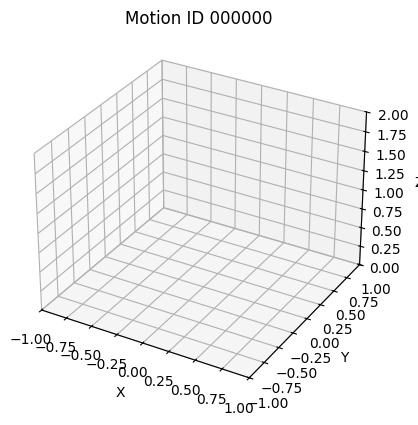

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path

# === Set paths ===
base_path = Path(".\\")
motion_file = base_path / "new_joints" / "000000.npy"  # motion ID 000000

# === Load motion ===
motion = np.load(motion_file)  # shape: (frames, joints, 3)
num_frames, num_joints, _ = motion.shape

# === Optional: define skeleton connections (parent, child indices) ===
# This depends on the skeleton used; here’s an example for SMPL 22 joints
skeleton = [
    (0,1),(1,2),(2,3),(0,4),(4,5),(5,6),
    (0,7),(7,8),(8,9),(0,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(0,16),(16,17),(17,18),
    (0,19),(19,20),(20,21)
]

# === Set up the figure ===
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_zlim(0,2)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Motion ID 000000')

# Scatter for joints
joints_scatter = ax.scatter([], [], [], c='r', s=20)
# Lines for bones
lines = [ax.plot([], [], [], c='b')[0] for _ in skeleton]

# === Update function for animation ===
def update(frame_idx):
    joints = motion[frame_idx]
    joints_scatter._offsets3d = (joints[:,0], joints[:,1], joints[:,2])
    
    # update bones
    for idx, (p, c) in enumerate(skeleton):
        lines[idx].set_data([joints[p,0], joints[c,0]], [joints[p,1], joints[c,1]])
        lines[idx].set_3d_properties([joints[p,2], joints[c,2]])
    return lines + [joints_scatter]

# === Create animation ===
ani = FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)
plt.show()
